In [1]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data = pd.read_csv(
    "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/geyser.csv"
)

print(data.head())

   duration  waiting   kind
0     3.600       79   long
1     1.800       54  short
2     3.333       74   long
3     2.283       62  short
4     4.533       85   long


In [3]:
print(data.shape)
print(data.isnull().sum())

(272, 3)
duration    0
waiting     0
kind        0
dtype: int64


In [4]:
x = data[['waiting', 'duration']].values

print(x[:5])

[[79.     3.6  ]
 [54.     1.8  ]
 [74.     3.333]
 [62.     2.283]
 [85.     4.533]]


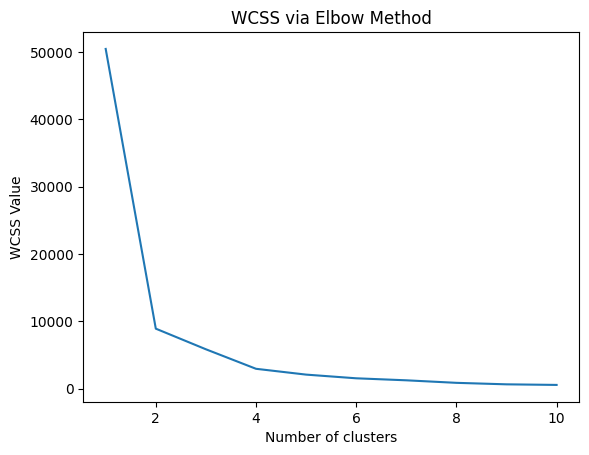

In [5]:
wcss = []

for i in range(1, 11):
    model = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=21
    )

    model.fit(x)
    wcss.append(model.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('WCSS via Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS Value')
plt.show()

In [6]:
model = KMeans(
    n_clusters=2,
    init='k-means++',
    random_state=42
)

y_means = model.fit_predict(x)

print(y_means)

[0 1 0 1 0 1 0 0 1 0 1 0 0 1 0 1 1 0 1 0 1 1 0 0 0 0 1 0 0 0 0 0 1 0 0 1 1
 0 1 0 0 1 0 1 0 0 1 1 0 1 0 0 1 0 1 0 0 1 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0
 1 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 1 0 1 0 0 0 1 0 1 0 1 0 0 1 0 1 0 0 0
 1 0 0 1 0 1 0 1 0 1 0 0 1 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 0 1 0 0 0 1 0 1
 0 1 0 0 1 0 0 0 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 1 0 0 0 0 0 1 0 0 1 0 0 0 1
 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1 0 0 1 0 0 0 1 0 1 0 1 0 1 0 1 0
 1 0 0 0 0 0 0 0 0 1 0 1 0 1 1 0 0 1 0 1 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0 0 1
 0 0 0 1 0 1 1 0 0 1 0 1 0]


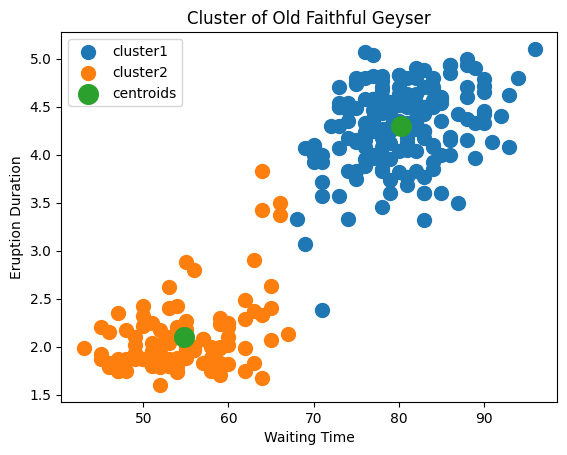

In [7]:
plt.scatter(
    x[y_means == 0, 0],
    x[y_means == 0, 1],
    s=100,
    label='cluster1'
)

plt.scatter(
    x[y_means == 1, 0],
    x[y_means == 1, 1],
    s=100,
    label='cluster2'
)

plt.scatter(
    model.cluster_centers_[:, 0],
    model.cluster_centers_[:, 1],
    s=200,
    label='centroids'
)

plt.title('Cluster of Old Faithful Geyser')
plt.xlabel('Waiting Time')
plt.ylabel('Eruption Duration')
plt.legend()
plt.show()